# **Install Dependencies**

In [1]:
"""
textstat- calculates statistical features from text.
          useful for quantifying text complexity and readability.
          This makes the library valuable for content analysis
          and assessment, as well as document classification tasks
plotly- beautiful interactive charts, whereas matplotlib provides static images
"""

!pip install -q textstat plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 63.8 MB/s eta 0:00:00


### **Import Statements**

`re` — Regular expressions (regex) are patterns used to search and extract text.

`Counter` — a special dictionary that automatically counts how many times each item appears. Perfect for word frequency

In [2]:
import re
from collections import Counter
import textstat
import plotly.graph_objects as go # for low-level, highly customizable chart objects (gauge)
import plotly.express as px # a high-level API for quickly creating common and beautiful statistical charts (bar, scatter, line)
from IPython.display import display

# **The Analysis Engine**

### **Tokenizer Function**

In [3]:
# \b- text boundary
# r- raw string
# [a-z]- any single lowercase letter from a to z
# +- one or more of the previous thing (so [a-z]+ = one or more letters = a whole word)

# this function finds every individual whole word
# This automatically removes punctuation, numbers, and special characters
def clean_and_tokenize(text):
    words = re.findall(r'\b[a-z]+\b', text.lower())
    return words

### **Stop Words**

In [4]:
# manual stop words
def get_stop_words():
    return set([
        "the", "a", "an", "and", "or", "but", "in", "on", "at", "to",
        "for", "of", "with", "is", "was", "are", "were", "be", "been",
        "have", "has", "had", "do", "does", "did", "will", "would",
        "could", "should", "may", "might", "this", "that", "it", "its",
        "i", "you", "he", "she", "we", "they", "my", "your", "not", "as"
    ])

### **Word Statistics**

In [5]:
def get_word_stats(text):
    words = clean_and_tokenize(text) # converts all words in lowercase
    stop_words = get_stop_words()
    filtered_words = [w for w in words if w not in stop_words] # contains only meaningful words w/o stop words. each sentence is an item in this list
    char_len = [len(w) for w in words]

    return { # returning a dictionary (the same happens with the 3 other functions below)
        "total_words": len(words), # total words (items in list) in the sentence w stop words
        "unique_words": len(set(words)), # unique words in the sentence w stop words
        "top_keywords": Counter(filtered_words).most_common(15), # most_common(15) returns the top 15 as a list of tuples
        "avg_word_length": round(sum(char_len) / len(words), 2) if words else 0, # length of each word on avg
        "lexical_diversity": round(len(set(words)) / len(words), 3) if words else 0 # number of words repeated
        # Lexical diversity = how varied the vocabulary is (closer to 1 = more varied)
    }

"""
ratio of different unique word stems (types)
to the total number of words (tokens)

Unique words ÷ total words = lexical diversity
> If we have 100 words and 80 are unique, diversity = 0.80 - varied vocabulary
> If we have 100 words and 20 are unique, diversity = 0.20 - repetitive text
"""

'\nratio of different unique word stems (types)\nto the total number of words (tokens)\n\nUnique words ÷ total words = lexical diversity\n> If we have 100 words and 80 are unique, diversity = 0.80 - varied vocabulary\n> If we have 100 words and 20 are unique, diversity = 0.20 - repetitive text\n'

### **Sentence Statistics**

text > split into sentences > calculate length of each sentence

In [6]:
# + means "one or more" - so "!!" or "..." counts as one split point, not multiple

def get_sentence_stats(text):
    sentences = re.split(r'[.!?]+', text) # splits sentences: a list of sentence strings
    """
    * if len(s.strip()) > 0

    After splitting on punctuation, we sometimes get empty strings "" at the end
    This filters them out - we only keep sentences that actually have content
    """
    sentences = [s.strip() for s in sentences if len(s.strip()) > 0] # s- each sentence
    sentence_len = [len(s.split()) for s in sentences] # split a sentence into words by spaces (unless we specify a delimeter), and calculate lengths of each (sentence length= no. of words)

    return {
        "total_sentences": len(sentences),
        "avg_sentence_length": round(sum(sentence_len) / len(sentence_len), 2) if sentence_len else 0,
        "longest_sentence": max(sentence_len) if sentence_len else 0,
        "shortest_sentence": min(sentence_len) if sentence_len else 0,
    }

### **Readability Scores**

More about textstat:

1. automatically counts syllables in every word using its internal algorithm.
2. When we pass text to any textstat function, it first silently calculates:
*   `textstat.syllable_count(text)`   # total syllables in entire text
*   `textstat.lexicon_count(text)`    # total words
*   `textstat.sentence_count(text)`   # total sentences

About ***`Flesch Reading Ease`***:

* Developed by Rudolf Flesch in 1948
* One of the **oldest** and **most trusted** readability formulas in the world. Still used today by governments, publishers, and insurance companies to ensure documents are understandable
* Formula: Reading Ease = 206.835
             - (1.015  × average words per sentence)
             - (84.6   × average syllables per word) [206.835- base score]
* Easy texts contain small amount of syllables and short sentences
* Hard texts contain huge amount of syllables and long sentences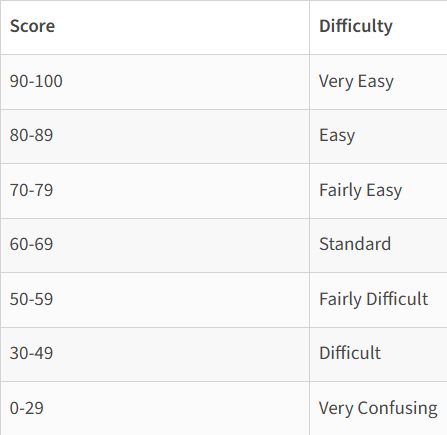

**Why This Matters in NLP**

---

Later, when we build text summarizers or content generators, we'll use this score to evaluate our output quality. A good summarizer should produce text with a higher reading ease than the original - it should simplify, not complicate.

About ***`Flesch Kincaid Grade`***:

* Created by Flesch and Kincaid (working for the US Navy in 1975)
* to help the military check if their manuals were understandable by recruits
* Same ingredients as Reading Ease, but the output is mapped to a US school grade level instead of a 0-100 score
* Formula: Grade Level = (0.39  × average words per sentence)
            + (11.8  × average syllables per word)
            - 15.59
* Long sentences → higher grade needed
* Words with more syllables → higher grade needed
* The result is a school grade number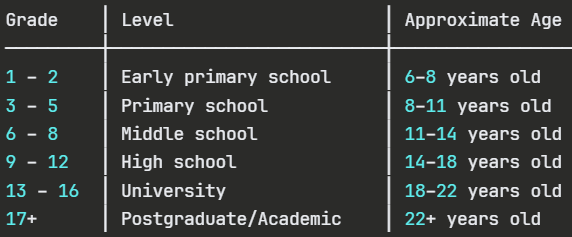

About ***`Reading Time`***:

* time needed to read a text
* Formula: Reading Time (ms) = number of characters × ms_per_char /
Reading Time (s)  = Reading Time (ms) ÷ 1000
* This is actually a useful feature - if we're building an app for children or non-native English speakers, we'd use a higher ms_per_char value to give a more realistic estimate as this group of people are slow/beginner readers

In [7]:
def get_readability(text):
    return {
        # Score 0-100. Higher = easier to read. 60-70 = plain English
        "flesch_reading_ease": textstat.flesch_reading_ease(text),

        # US school grade level needed to understand the text
        "flesch_kincaid_grade": textstat.flesch_kincaid_grade(text),

        # the speed vaue of 14.69 is for average speakers (can be modified for slow-20.0 or fast-8.0 readers)
        "reading_time_seconds": textstat.reading_time(text, ms_per_char=14.69),
    }

### **Tone Detection**

In [8]:
def get_tone_indicators(text):
    """
    Simple rule-based tone detection.
    Not ML - just keyword matching.
    """
    text_lower = text.lower() # converting every word to lowercase to maintain equality

    """
    key: tone
    value: list of keywords

    lexicon-based/rule-based sentiment/tone detection
    """
    tone_keywords = {
        "Positive 😊": ["great", "excellent", "amazing", "love", "wonderful", "fantastic",
                        "good", "happy", "success", "best", "brilliant", "improve", "wow", "marvelous"],
        "Negative 😟": ["bad", "terrible", "awful", "hate", "worst", "fail", "problem",
                        "difficult", "unfortunately", "poor", "wrong", "never", "awful"],
        "Formal 🎩":   ["therefore", "furthermore", "consequently", "hereby", "whereas",
                        "shall", "pursuant", "accordingly", "notwithstanding"],
        "Urgent ⚡":   ["immediately", "urgent", "asap", "critical", "deadline", "now",
                        "must", "required", "emergency", "priority"],
    }

    scores = {}
    for tone, keywords in tone_keywords.items(): # .items() gives key-value pairs in each loop
        matches = [kw for kw in keywords if kw in text_lower]
        scores[tone] = len(matches) #store how many tone keywords were found for each tone category. iterates over each tone at a time (tone:length-match pairs)

    # here we're finding the key with the greatest value
    # checks which tone had the most keyword matches
    # assigns the tone (key) with the highest keyword count from the scores dictionary to dominant_tone
    dominant_tone = max(scores, key=scores.get) if any(scores.values()) else "Neutral 😐"
    return {
        "scores": scores,
        "dominant": dominant_tone,
    }

# **The Visualizer**

In [9]:
def full_analysis(text):
    return {
        "word_statistics": get_word_stats(text), # each of them are subdictionaries
        "sentence_statistics": get_sentence_stats(text),
        "readability": get_readability(text),
        "tone": get_tone_indicators(text),
    }

In [10]:
def dashboard(text):
    results = full_analysis(text)
    ws = results["word_statistics"] # each dictionary
    ss = results["sentence_statistics"]
    rd = results["readability"]
    tone = results["tone"]

    # ── WORD+SENTENCE STATS ──────────────────────────────
    print("=" * 45)
    print("         📊 TEXT ANALYSIS DASHBOARD")
    print("=" * 45)

    print("\n📌 SUMMARY")
    print(f"  Total Words       : {ws['total_words']}") # accesses 'total_words' key from word_statistics dict
    print(f"  Unique Words      : {ws['unique_words']}")
    print(f"  Total Sentences   : {ss['total_sentences']}")
    print(f"  Lexical Diversity : {ws['lexical_diversity']}  (1.0 = every word unique)")
    print(f"  Average Word Length   : {ws['avg_word_length']} characters")
    print(f"  Average Sentence Length  : {ss['avg_sentence_length']} words")

    # ── READABILITY SCORES ──────────────────────────────
    ease = rd["flesch_reading_ease"] # accesses 'flesch_reading_ease' key from readability dict
    grade = rd["flesch_kincaid_grade"]
    reading_secs = rd["reading_time_seconds"]
    mins = int(reading_secs // 60) # floor division to calculate the full minutes
    secs = int(reading_secs % 60) # modulo to calculate the seconds (remainder)

    if ease >= 90:
        ease_label = "Very Easy to Read"
    elif ease >= 80:
        ease_label = "Easy to Read"
    elif ease >= 70:
        ease_label = "Fairly Easy to Read"
    elif ease >= 60:
        ease_label = "Standard to Read"
    elif ease >=50:
        ease_label = "Fairly Difficult to Read"
    elif ease >= 30:
        ease_label = "Difficult to Read"
    else: # if ease >=29
        ease_label = "Very Confusing to Read"

    print("\n📖 READABILITY")
    print(f"  Reading Ease Score : {ease:.2f} — {ease_label}")
    print(f"  Grade Level        : US Grade {grade:.2f}")
    print(f"  Estimated Reading  : {mins}minutes {secs}seconds")

    # ── TONE DETECTION ─────────────────────────────────────
    print("\n🎭 TONE ANALYSIS")
    print(f"  Dominant Tone : {tone['dominant']}") # the tone which appeared the most
    print("  Breakdown:")
    for t, score in tone["scores"].items(): # the scores subdictionary actually, which is inside the tone dictionary
        bar = "█" * score if score > 0 else "░"
        print(f"    {t:<20} {bar} ({score})") # t:<20->value of t will be left-aligned within a field of 20 chars

    """
    Example:

    tone_scores = {"Positive": 3, "Negative": 0, "Urgent": 1} # an example of what kind of scores dictionary we get
    print("Example output for tone bars:")
    for t, score in tone_scores.items():
        bar = "█" * score if score > 0 else "░"
    """

    # ── TOP KEYWORDS ─────────────────────────────

    # enumerate is used to fetch the index (i) and the item (word, count) during each iteration
    # counting should start from 1 instead of default 0
    print("\n🔑 TOP KEYWORDS (stop words removed)")
    for i, (word, count) in enumerate(ws["top_keywords"], 1): # top_keywords contains tuples, where each tuple is (word, count)
        bar = "█" * count
        print(f"  {i:>2}. {word:<20} {bar} ({count})") # >2- right align 2 chars; <20- left aligns 20 chars

    print("\n" + "~" * 45)

Code documentation about ***`Gauges`***:

* `go.Figure()` creates a blank canvas, so whatever we pass inside it goes onto the canvas
* `go.Indicator` is the chart type, which specialises in displaying single numbers visually
* `mode`tells Plotly how to display the indicator [`gauge`- semicircle dial; `number`- actual no. in middle]. we show both together
* `value` is the actual number the gauge needle points to
* `gauge` dictionary controls everything about the gauge's appearance
* `bar` is the needle pointer of the gauge
* `steps` paint background colors onto different sections of the gauge
* `update_layout` modifies the container around the chart

In [14]:
def visuals(text):
  results = full_analysis(text)
  ws = results["word_statistics"] # each dictionary
  rd = results["readability"]
  tone = results["tone"]
  ease = rd["flesch_reading_ease"]

  # ── Plotly Charts ───────────────────────────────────────

  # Reading Ease Gauge
  fig1 = go.Figure(go.Indicator( # store the chart in `fig1` variable
      mode="gauge+number", # other options- "number", "delta", "number+delta"
      value=ease,

      # the title is a dictionary {} not just a string.
      # Plotly uses dictionaries for most settings because
      # we can add more options later like font size, color, etc.
      title={"text": "Reading Ease Score (0 = Hard, 100 = Easy)"},
      gauge={
          "axis": {"range": [0, 100]}, # min and max of the gauge dial, because ease value is till 100
          "bar": {"color": "royalblue"}, # can also use hex code
          "steps": [
              {"range": [0, 30],  "color": "#ff4b4b"}, # each step is a dict with 2 keys (range and color)
              {"range": [30, 60], "color": "#ffa500"},
              {"range": [60, 100],"color": "#21c354"},
          ],
      }
  ))
  fig1.update_layout(height=300, margin=dict(t=40, b=10)) # 300px tall chart; t- top; b- bottom
  fig1.show() # renders and displays the chart

  # Keyword Frequency Bar Chart
  if ws["top_keywords"]:
      keywords, counts = zip(*ws["top_keywords"])
      fig2 = px.bar(
          x=list(counts),
          y=list(keywords),
          orientation="h",
          color=list(counts),
          color_continuous_scale="Blues",
          title="🔑 Top Keywords by Frequency",
          labels={"x": "Frequency", "y": "Keyword"}
      )
      fig2.update_layout(yaxis={"categoryorder": "total ascending"}, height=420)
      fig2.show()

  # Tone Breakdown
  tone_names  = list(tone["scores"].keys())
  tone_values = list(tone["scores"].values())
  fig3 = px.bar(
      x=tone_names,
      y=tone_values,
      color=tone_names, # color by category names
      title="🎭 Tone Indicator Strengths",
      labels={"x": "Tone", "y": "Keyword Matches"},
      # px.colors.qualitative = a collection of color palettes designed for categories
      # Other options: .Bold, .Vivid, .Safe, .Antique, .Dark24
      color_discrete_sequence=px.colors.qualitative.Pastel # categories → each gets its own distinct color
  )

  """
  By default Plotly adds a legend on the side when you use color
  But here the bar labels already tell you which tone is which- a legend would be redundant
  showlegend=False hides it to keep the chart clean
  """

  fig3.update_layout(showlegend=False, height=350)
  fig3.show()

  # Sentence Complexity
  sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]
  sent_lengths = [len(s.split()) for s in sentences]
  sent_labels  = [f"S{i+1}" for i in range(len(sentences))]

  fig4 = px.bar(
      x=sent_labels,
      y=sent_lengths,
      color=sent_lengths,
      color_continuous_scale="Teal",
      title="📝 Sentence Complexity (word count per sentence)",
      labels={"x": "Sentence", "y": "Word Count"}
  )
  fig4.show()

### **Main/Wrapper Function**
This is where all the functions above run finally, which calls all analysis functional and bundles their results into one neat dictionary. Instead of calling the functions separately every time, we call this one and get everything back at once!

In [15]:
def display(text):
  dashboard(text)
  visuals(text)

In [16]:
# sample_text = input(("Enter your text to analyze: "))

sample_text = """
Artificial Intelligence is transforming industries   at an unprecedented Pace.
Companies that fail to adapt will unfortunately fall behind. The opportunities
are tremendous for those who embrAce change. However, the CHALLENGES are equally
significant....  Building great AI systems requires not just technical expertise,
but also a deep understanding of human needs and   ethical considerations!! Now,
What Should Be Done??? Therefore, leaders must act immediately to implement these
critical changes across their organizations.
"""

display(sample_text)

         📊 TEXT ANALYSIS DASHBOARD

📌 SUMMARY
  Total Words       : 71
  Unique Words      : 68
  Total Sentences   : 7
  Lexical Diversity : 0.958  (1.0 = every word unique)
  Average Word Length   : 6.14 characters
  Average Sentence Length  : 10.14 words

📖 READABILITY
  Reading Ease Score : 24.96 — Very Confusing to Read
  Grade Level        : US Grade 12.30
  Estimated Reading  : 0minutes 6seconds

🎭 TONE ANALYSIS
  Dominant Tone : Urgent ⚡
  Breakdown:
    Positive 😊           █ (1)
    Negative 😟           ██ (2)
    Formal 🎩             █ (1)
    Urgent ⚡             ████ (4)

🔑 TOP KEYWORDS (stop words removed)
   1. artificial           █ (1)
   2. intelligence         █ (1)
   3. transforming         █ (1)
   4. industries           █ (1)
   5. unprecedented        █ (1)
   6. pace                 █ (1)
   7. companies            █ (1)
   8. fail                 █ (1)
   9. adapt                █ (1)
  10. unfortunately        █ (1)
  11. fall                 █ (1)
  12. beh